In [1]:
import torch

# Check if CUDA is available
train_on_gpu = torch.cuda.is_available()

if not train_on_gpu:
    print('CUDA is not available. Training on CPU...')
else:
    print('CUDA is available! Training on GPU...')

"""# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')"""

"""# Path to the root directory where LibriSpeech is stored. also loading a sample file.
librispeech_train = "/content/drive/My Drive/DL/DL_proj/LibriSpeech/train-clean-100/"
audio_path = "/content/drive/My Drive/DL/DL_proj/LibriSpeech/test-clean/121/121726/121-121726-0000.flac"""



CUDA is available! Training on GPU...


'# Path to the root directory where LibriSpeech is stored. also loading a sample file.\nlibrispeech_train = "/content/drive/My Drive/DL/DL_proj/LibriSpeech/train-clean-100/"\naudio_path = "/content/drive/My Drive/DL/DL_proj/LibriSpeech/test-clean/121/121726/121-121726-0000.flac'

In [2]:
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path
import torchaudio

from kiwano.features import Fbank



data_dir = Path("/home/hleguilier/Documents/Thèse/Resnet34/kiwano/recipes/resnet/data/voxceleb1/wav")

/home/hleguilier/anaconda3/envs/speaker-verification/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/hleguilier/anaconda3/envs/speaker-verification/lib/python3.9/site-packages/torchvision/datapoints/__init__.py:12: UserWarning: The torchvision.datapoints and torchvision.transforms.v2 namespaces are still Beta. While we do not expect major breaking changes, some APIs may still change according to user feedback. Please submit any feedback you may have in this issue: https://github.com/pytorch/vision/issues/6753, and you can also check out https://github.com/pytorch/vision/issues/7319 to learn more about the APIs that we suspect might involve future changes. You can silence this warning by calling torchvision.disable_beta_transforms_warning().
  warnings.warn(_BETA_TRANSFORMS_WARNING)
/home/hleguilier

In [3]:
def find_audio_files(directory, extension=".wav"):
    """
    Parcourt récursivement l'arborescence pour trouver les fichiers audio.
    """
    if not directory.exists():
        print(f"Erreur : le répertoire {directory} n'existe pas.")
        return []

    audio_files = sorted(directory.rglob(f"*{extension}"))
    print(f"Fichiers trouvés ({len(audio_files)}):")
    for f in audio_files[:5]:  # Affiche les 5 premiers fichiers pour validation
        print(f)
    return audio_files


In [8]:
# Recherche des fichiers .wav
audio_files = find_audio_files(data_dir)
print(f"Nombre de fichiers audio trouvés : {len(audio_files)}")

# Charger un fichier audio pour test
#audio_path = str(audio_files[3])
audio_path = "/home/hleguilier/Documents/Thèse/Resnet34/kiwano/recipes/resnet/data/voxceleb1/wav/id10111/rwN0Jpxfi44/00002.wav"
print(f"Chargement du fichier audio : {audio_path}")


Fichiers trouvés (153516):
/home/hleguilier/Documents/Thèse/Resnet34/kiwano/recipes/resnet/data/voxceleb1/wav/id10001/1zcIwhmdeo4/00001.wav
/home/hleguilier/Documents/Thèse/Resnet34/kiwano/recipes/resnet/data/voxceleb1/wav/id10001/1zcIwhmdeo4/00002.wav
/home/hleguilier/Documents/Thèse/Resnet34/kiwano/recipes/resnet/data/voxceleb1/wav/id10001/1zcIwhmdeo4/00003.wav
/home/hleguilier/Documents/Thèse/Resnet34/kiwano/recipes/resnet/data/voxceleb1/wav/id10001/7gWzIy6yIIk/00001.wav
/home/hleguilier/Documents/Thèse/Resnet34/kiwano/recipes/resnet/data/voxceleb1/wav/id10001/7gWzIy6yIIk/00002.wav
Nombre de fichiers audio trouvés : 153516
Chargement du fichier audio : /home/hleguilier/Documents/Thèse/Resnet34/kiwano/recipes/resnet/data/voxceleb1/wav/id10111/rwN0Jpxfi44/00002.wav


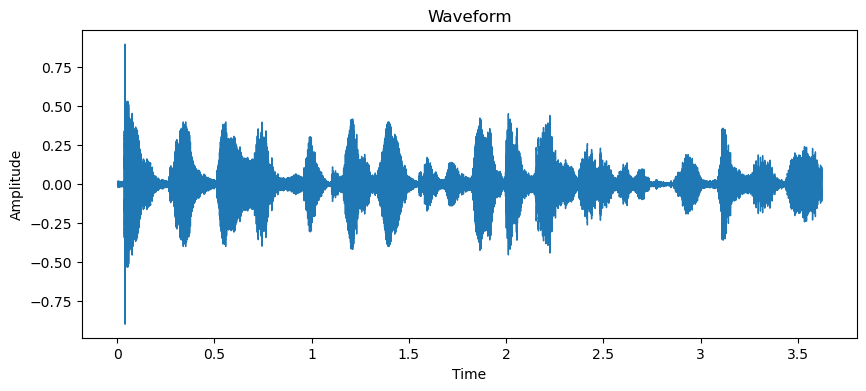

In [9]:
# Load the audio file
y, sr = librosa.load(audio_path)

if len(y) == 0:
    print(f"Fichier audio vide ou problème de chargement : {audio_path}")


# Plot the raw audio waveform
plt.figure(figsize=(10, 4))
librosa.display.waveshow(y, sr=sr)
plt.title('Waveform')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.show()


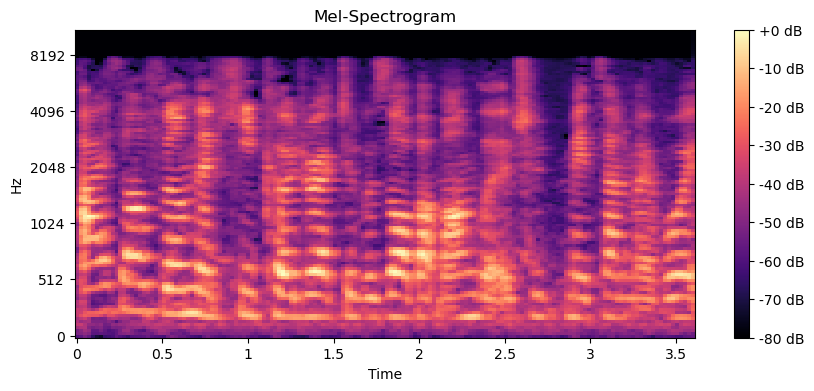

In [10]:
# Compute mel-spectrogram
mel_spec = librosa.feature.melspectrogram(y=y, sr=sr)

# Convert power spectrogram to dB (decibel) units
mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

# Plot the mel-spectrogram
plt.figure(figsize=(10, 4))
librosa.display.specshow(mel_spec_db, sr=sr, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title('Mel-Spectrogram')
plt.show()


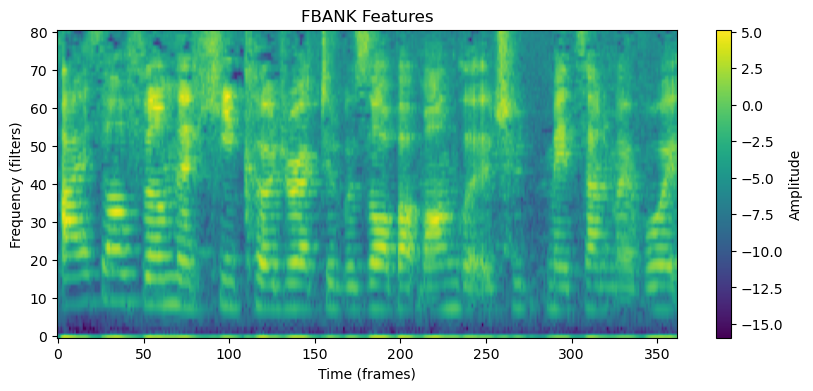

In [11]:
# Instancier Fbank
fbank_extractor = Fbank()
waveform, sample_rate = torchaudio.load(audio_path)

# Extraire les FBANK
fbank_features = fbank_extractor.extract(waveform.squeeze(0).numpy(), sampling_rate=sample_rate)

# Visualiser les FBANK
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 4))
plt.imshow(fbank_features.T, aspect='auto', origin='lower')
plt.colorbar(label="Amplitude")
plt.title("FBANK Features")
plt.xlabel("Time (frames)")
plt.ylabel("Frequency (filters)")
plt.show()

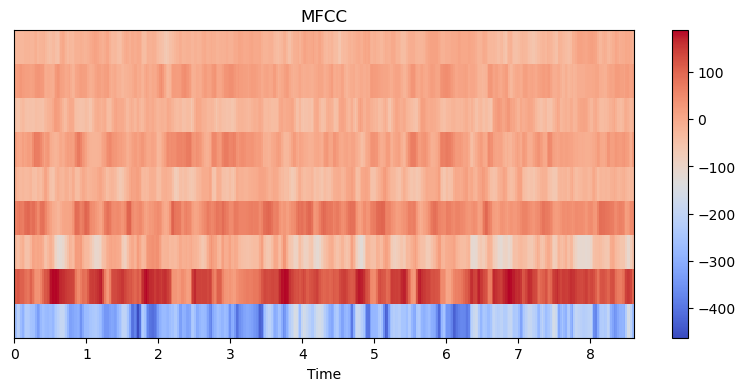

In [33]:
# Compute MFCCs
mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=9)

# Plot the MFCCs
plt.figure(figsize=(10, 4))
librosa.display.specshow(mfccs, sr=sr, x_axis='time')
plt.colorbar()
plt.title('MFCC')
plt.show()


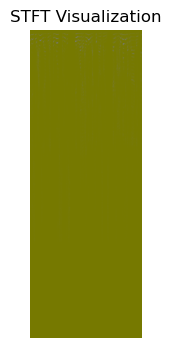

In [34]:
import librosa
import numpy as np
import matplotlib.pyplot as plt

y, sr = librosa.load(audio_path)

# Compute the Short-Time Fourier Transform (STFT)
D = librosa.stft(y)

# Separate real and imaginary parts
D_real = np.real(D)
D_imag = np.imag(D)

# Compute magnitude of STFT
magnitude = np.abs(D)

# Normalize each channel to [0, 1]
D_real_normalized = (D_real - D_real.min()) / (D_real.max() - D_real.min())
D_imag_normalized = (D_imag - D_imag.min()) / (D_imag.max() - D_imag.min())
magnitude_normalized = (magnitude - magnitude.min()) / (magnitude.max() - magnitude.min())

# Create the RGB image
rgb_image = np.stack((D_real_normalized, D_imag_normalized, magnitude_normalized), axis=-1)

# Plot the RGB image
plt.figure(figsize=(10, 4))
plt.imshow(rgb_image)
plt.title('STFT Visualization')
plt.axis('off')
plt.show()


In [35]:
import librosa
import numpy as np
import matplotlib.pyplot as plt
from skimage.transform import resize
y, sr = librosa.load(audio_path)

# Compute the Short-Time Fourier Transform (STFT)
D = librosa.stft(y)

# Separate magnitude and phase
magnitude = np.abs(D)
phase = np.angle(D)

# Normalize magnitude to [0, 1]
magnitude_normalized = (magnitude - magnitude.min()) / (magnitude.max() - magnitude.min())

# Normalize phase to [0, 2*pi] and map it to [0, 1]
phase_normalized = (phase + np.pi) / (2 * np.pi)

# Combine magnitude and phase into an RGB image
rgb_image = np.zeros((magnitude.shape[0], magnitude.shape[1], 3))
rgb_image[:, :, 0] = magnitude_normalized  # Red channel: Magnitude
rgb_image[:, :, 1] = phase_normalized      # Green channel: Phase
rgb_image[:, :, 2] = 0.5                   # Blue channel: Constant value (adjust as needed)
rgb_image.resize(40, 120)
# Plot the RGB image
plt.figure(figsize=(4, 4))
plt.imshow(rgb_image)
plt.title('STFT Visualization')
plt.axis('off')
plt.show()


ModuleNotFoundError: No module named 'skimage'